In [249]:
!pip install sqlalchemy pyodbc pandas

Understanding the dataset to explore how the data is present in the database ans if there is a need of creating some aggregate tables that can help with:>
1. vendor selection for profitabilty 2- Product Pricing Optimization

In [5]:
import pandas as pd
from sqlalchemy import create_engine
import os

In [8]:
import pyodbc
for driver in pyodbc.drivers():
    print(driver)

SQL Server
ODBC Driver 17 for SQL Server
ODBC Driver 18 for SQL Server
Microsoft Access Driver (*.mdb, *.accdb)
Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)
Microsoft Access Text Driver (*.txt, *.csv)
Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)


In [12]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

server = r'HEMANT\SQLEXPRESS'
database = 'inventory'
driver = 'ODBC Driver 17 for SQL Server'

params = urllib.parse.quote_plus(
    f"DRIVER={driver};SERVER={server};DATABASE={database};Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

print("✅ Engine ready")

✅ Engine ready


In [121]:
# !pip install os

In [30]:
import os
import pandas as pd
def ingest_db(df,table_name,engine):
    df.to_sql(table_name,con =engine,if_exists='replace',index=False,)

def  load_raw_data():
    data_path =r'D:\ConsoleFlare\Project\project_datasets'
    for file in os.listdir(data_path):
        if '.csv' in file:
            print(file)
            file_path =os.path.join(data_path, file)
            df = pd.read_csv(file_path)
            print(df.shape)
            ingest_db(df,file[:-4],engine)

load_raw_data()

begin_inventory.csv
(206529, 9)
brand_need_Promotion_Pricing_Adjustment.csv
(7, 3)
end_inventory.csv
(224489, 9)
purchases.csv
(484066, 16)
purchase_prices.csv
(12261, 9)
sales.csv
(432356, 14)
vendor_invoice.csv
(5543, 10)


In [33]:
# checking tables present in the SQL Server database
query = "SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE = 'BASE TABLE'"
tables = pd.read_sql_query(query, engine)

print(tables)

                                TABLE_NAME
0                          begin_inventory
1  brand_need_Promotion_Pricing_Adjustment
2                            end_inventory
3                                purchases
4                          purchase_prices
5                                    sales
6                           vendor_invoice
7                     vendor_sales_summary


In [35]:
#TO CHECK NO OF RECORD OF ANY TABLE
for table in tables['TABLE_NAME']:
    print('-'*50,f'{table}','-'*50)
    print('Count of record :',pd.read_sql(f'Select count(*) as count from {table}',engine)['count'].values[0])
    display(pd.read_sql(f'select top 5 * from {table}',engine))  # syntax change

-------------------------------------------------- begin_inventory --------------------------------------------------
Count of record : 206529


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


-------------------------------------------------- brand_need_Promotion_Pricing_Adjustment --------------------------------------------------
Count of record : 7


,Description,TotalSalesDollars,ProfitMargin
0,Three Olives Grape Vodka,5.94,88.047
1,Absolut Pears,35.82,91.122
2,St Elder Elderflower Liqueur,48.51,88.291
3,Mojoshot Blue Lagoon RTD,48.51,95.485
4,12 Days of Pearls Gift Set,49.95,85.606


-------------------------------------------------- end_inventory --------------------------------------------------
Count of record : 224489


...

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375,1,0.79,12546,JIM BEAM BRANDS COMPANY


-------------------------------------------------- vendor_invoice --------------------------------------------------
Count of record : 5543


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


-------------------------------------------------- vendor_sales_summary --------------------------------------------------
Count of record : 7153


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750,5,119.30,0.00,0.00,0,0.00,27.08,-119.30,NaN,0.000,0.000
1,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750,57,2035.47,199.96,199.96,4,3.16,62.39,-1835.51,-917.939,0.002,0.098
2,287,APPOLO VINEYARDS LLC,24921,Appolo Vyds Seyval,10.40,15.49,750,12,124.80,0.00,0.00,0,0.00,12.28,-124.80,NaN,0.000,0.000
3,388,ATLANTIC IMPORTING COMPANY,2034,Glendalough Double Barrel,21.32,32.99,750,587,12514.84,1507.48,1391.52,52,41.05,211.74,-11007.36,-730.183,0.004,0.120
4,388,ATLANTIC IMPORTING COMPANY,2119,Glendalough 13 Yr Sngle Malt,66.40,89.99,750,21,1394.40,254.97,254.97,3,2.37,211.74,-1139.43,-446.888,0.002,0.183


In [36]:
purchases = pd.read_sql("""select * from purchases where VendorNumber = 4466 """,engine)
purchases.head()

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,62_KILMARNOCK_5255,62,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8995,2024-02-19,2024-02-24,2024-03-07,2024-04-02,9.35,6,56.10,1
1,67_EANVERNESS_5215,67,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8995,2024-02-19,2024-02-25,2024-03-07,2024-04-02,9.41,5,47.05,1
2,76_DONCASTER_5215,76,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8995,2024-02-19,2024-02-26,2024-03-07,2024-04-02,9.41,5,47.05,1
3,2_ASHBORNE_5255,2,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8995,2024-02-19,2024-02-25,2024-03-07,2024-04-02,9.35,6,56.10,1
4,59_CLAETHORPES_5255,59,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8995,2024-02-19,2024-02-26,2024-03-07,2024-04-02,9.35,6,56.10,1


In [37]:
purchases.groupby(['Brand','PurchasePrice'])[['Quantity','Dollars']].sum()

,,Quantity,Dollars
Brand,PurchasePrice,,
5215,9.41,1021,9607.61
5255,9.35,1096,10247.60


In [38]:
# TO Check One specific vendor details - so selected vendorName = 4466 from purchase_price table
purchases_price = pd.read_sql("""Select * from purchase_prices where VendorNumber = 4466""",engine)
purchases_price.head()

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,5215,TGI Fridays Long Island Iced,12.99,1750mL,1750,1,9.41,4466,AMERICAN VINTAGE BEVERAGE
1,5255,TGI Fridays Ultimte Mudslide,12.99,1750mL,1750,1,9.35,4466,AMERICAN VINTAGE BEVERAGE
2,3140,TGI Fridays Orange Dream,14.99,1750mL,1750,1,11.19,4466,AMERICAN VINTAGE BEVERAGE


In [39]:
# To check one specific vendor detail - so selected VendorNumber = 4466 from vendor invoice table
vendor_invoice = pd.read_sql(""" select * from vendor_invoice where VendorNumber = 4466""",engine)
vendor_invoice.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-19,8207,2023-12-27,2024-02-26,335,3142.33,16.97,None
2,4466,AMERICAN VINTAGE BEVERAGE,2024-01-18,8307,2024-01-03,2024-02-18,41,383.35,1.99,None
3,4466,AMERICAN VINTAGE BEVERAGE,2024-01-27,8469,2024-01-14,2024-03-11,72,673.20,3.30,None
4,4466,AMERICAN VINTAGE BEVERAGE,2024-02-04,8532,2024-01-19,2024-03-15,79,740.21,3.48,None


In [40]:
vendor_invoice['PONumber'].nunique()

55

Purchase Table is derived from the purchase_invoice and purchase_price

In [41]:
# to check one specific vendor details - so selected vendorName = 4466 from sales  table
sales = pd.read_sql("""Select * from sales where VendorNo = 4466""",engine)
sales.head()

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-09,1750,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
1,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-12,1750,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
2,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-15,1750,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
3,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-21,1750,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
4,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-23,1750,1,1.84,4466,AMERICAN VINTAGE BEVERAGE


In [42]:
sales_group_4466_vendor = sales.groupby('Brand')[['SalesDollars','SalesPrice','SalesQuantity']].sum().reset_index()
sales_group_4466_vendor.head()

,Brand,SalesDollars,SalesPrice,SalesQuantity
0,5215,1649.73,948.27,127
1,5255,2208.30,1519.83,170


In [43]:
purchase_group_4466_vendor = purchases.groupby(['Brand','PurchasePrice'])[['Quantity','Dollars']].sum().reset_index()
purchase_group_4466_vendor

,Brand,PurchasePrice,Quantity,Dollars
0,5215,9.41,1021,9607.61
1,5255,9.35,1096,10247.60


In [44]:
purchase_sales_4466_vendor = purchase_group_4466_vendor.merge(sales_group_4466_vendor,on = 'Brand')
purchase_sales_4466_vendor

,Brand,PurchasePrice,Quantity,Dollars,SalesDollars,SalesPrice,SalesQuantity
0,5215,9.41,1021,9607.61,1649.73,948.27,127
1,5255,9.35,1096,10247.60,2208.30,1519.83,170


In [45]:
purchase_sales_4466_vendor['Remianing_qty'] = purchase_sales_4466_vendor['Quantity'] - purchase_sales_4466_vendor['SalesQuantity']
purchase_sales_4466_vendor['Profit Dollars'] = purchase_sales_4466_vendor['SalesDollars'] - purchase_sales_4466_vendor['Dollars']
purchase_sales_4466_vendor['Sales % qty'] = ((purchase_sales_4466_vendor['SalesQuantity']/purchase_sales_4466_vendor['Quantity'])*100).round(2)
purchase_sales_4466_vendor.head()

,Brand,PurchasePrice,Quantity,Dollars,SalesDollars,SalesPrice,SalesQuantity,Remianing_qty,Profit Dollars,Sales % qty
0,5215,9.41,1021,9607.61,1649.73,948.27,127,894,-7957.88,12.44
1,5255,9.35,1096,10247.60,2208.30,1519.83,170,926,-8039.30,15.51


## Observation Points
* The Purchases table contains actual purchase data, including the data of purchase, product (Brand) purchase by vendor the amount paid and the   quantity purchase.

* The Purchase price column is derived from the purchase_price table. Which provides product-wise actual and purchases price.

* The vendor_invoice table aggregate data from the purchase table. summarizing Quantity and dollar amount, along with an additional column for    freight. This table maintains uniqueness based on vendor and PO number.

* The Sales table actual sales transactions detailing the brand purchases by vendors the quantity sold the selling price and the revenue earned.

As the data we need for analysis  is distributed tables, we need to create a summary table containing.

•	Purchase transaction made by vendors.

•	Sales transaction data.

•	Freight costs for each vendor.

•	Actual product price from vendors.


In [46]:
vendor_invoice.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='object')

In [47]:
freight_summary =pd.read_sql("""select VendorNumber,sum(Freight) as FreightCost from vendor_invoice group by VendorNumber""",engine)
freight_summary

,VendorNumber,FreightCost
0,6830,360.29
1,8920,232.99
2,17032,283.61
3,7749,91.50
4,4692,9139.38
...,...,...
121,11567,20964.81
122,2450,251.28
123,7239,16978.67
124,8664,18544.49


In [48]:
pd.read_sql_query("""select
p.VendorNumber,
p.VendorName,
p.Brand,
p.PurchasePrice,
pp.Price As ActualPrice,
pp.Volume,
sum(p.Quantity) As TotalPurchaseQuantity,
sum(p.Dollars) As TotalPurchaseDollars
from purchases p
join purchase_prices pp
on p.Brand = pp.Brand
Group By
p.VendorNumber,
p.VendorName,
p.Brand,
p.PurchasePrice,
pp.Price,
pp.Volume
Order BY TotalPurchaseDollars""",engine)

,VendorNumber,VendorName,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars
0,7245,PROXIMO SPIRITS INC.,3065,0.71,0.99,50,1,0.71
1,9165,ULTRA BEVERAGE COMPANY LLP,9191,0.73,0.99,50,3,2.19
2,9815,WINE GROUP INC,22407,2.25,3.29,750,1,2.25
3,3960,DIAGEO NORTH AMERICA INC,8729,0.74,0.99,50,4,2.96
4,17035,PERNOD RICARD USA,8063,1.59,1.99,50,2,3.18
...,...,...,...,...,...,...,...,...
7148,4425,MARTIGNETTI COMPANIES,3405,23.19,28.99,1750,20653,478943.07
7149,17035,PERNOD RICARD USA,8068,18.24,24.99,1750,27600,503424.00
7150,3960,DIAGEO NORTH AMERICA INC,3545,21.89,29.99,1750,28326,620056.14
7151,1128,BROWN-FORMAN CORP,1233,26.27,36.99,1750,28772,755840.44


As we can see There is 0 Value purchase price column it's not possible because any vendor can not purchase on 0 price so we need clean this data

In [49]:
pd.read_sql_query("""select
p.VendorNumber,
p.VendorName,
p.Brand,
p.PurchasePrice,
pp.Price As ActualPrice,
pp.Volume,
sum(p.Quantity) As TotalPurchaseQuantity,
sum(p.Dollars) As TotalPurchaseDollars
from purchases p
join purchase_prices pp
on p.Brand = pp.Brand
where p.PurchasePrice > 0
Group By
p.VendorNumber,
p.VendorName,
p.Brand,
p.PurchasePrice,
pp.Price,
pp.Volume
Order BY TotalPurchaseDollars""",engine)

,VendorNumber,VendorName,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars
0,7245,PROXIMO SPIRITS INC.,3065,0.71,0.99,50,1,0.71
1,9165,ULTRA BEVERAGE COMPANY LLP,9191,0.73,0.99,50,3,2.19
2,9815,WINE GROUP INC,22407,2.25,3.29,750,1,2.25
3,3960,DIAGEO NORTH AMERICA INC,8729,0.74,0.99,50,4,2.96
4,17035,PERNOD RICARD USA,8063,1.59,1.99,50,2,3.18
...,...,...,...,...,...,...,...,...
7148,4425,MARTIGNETTI COMPANIES,3405,23.19,28.99,1750,20653,478943.07
7149,17035,PERNOD RICARD USA,8068,18.24,24.99,1750,27600,503424.00
7150,3960,DIAGEO NORTH AMERICA INC,3545,21.89,29.99,1750,28326,620056.14
7151,1128,BROWN-FORMAN CORP,1233,26.27,36.99,1750,28772,755840.44


In [50]:
pd.read_sql_query("""select
vendorNo,
brand,
sum(SalesDollars) as TotalSalesDollars,
sum(salesPrice) as TotalSalesPrice,
sum(salesQuantity) as TotalSalesQuantity,
sum(ExciseTax) as TotalSalesTax
from sales
group by vendorNo, brand order by TotalSalesDollars
""",engine)

,vendorNo,brand,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalSalesTax
0,8004,5287,0.49,0.49,1,0.05
1,3960,3303,0.99,0.99,1,0.05
2,7245,3096,0.99,0.99,1,0.05
3,9625,8872,0.99,0.99,1,0.05
4,3960,8729,0.99,0.99,1,0.05
...,...,...,...,...,...,...
6395,4425,3405,106254.57,23662.11,3543,6509.61
6396,17035,8068,117084.76,22231.41,4524,8311.97
6397,1128,1233,138165.61,29727.74,3839,7053.50
6398,3960,3545,148816.57,24501.88,4943,9082.28


In [51]:
vendor_sales_summary = pd.read_sql_query("""
With FreightSummary AS(
    select
        vendorNumber,
        SUM(Freight) as FreightCost
    from vendor_invoice
    group by vendorNumber
),

PurchaseSummary AS(
    Select
        p.VendorNumber,
        p.VendorName,
        p.Brand,
        p.Description,
        p.PurchasePrice,
        pp.Price As ActualPrice,
        pp.Volume,
        sum(p.Quantity) As TotalPurchaseQuantity,
        sum(p.Dollars) As TotalPurchaseDollars
    from purchases p
    join purchase_prices pp
        On p.Brand = pp.Brand
    where p.PurchasePrice > 0
    Group By
        p.VendorNumber,
        p.VendorName,
        p.Brand,
        p.Description,
        p.PurchasePrice,
        pp.Price,
        pp.Volume
),

SalesSummary AS(
    Select
        vendorNo,
        Brand,
        sum(SalesDollars) as TotalsalesDollars,
        sum(salesPrice) as TotalsalesPrice,
        sum(salesQuantity) as TotalsalesQuantity,
        sum(ExciseTax) as TotalExciseTax
    from sales
    group by vendorNo, Brand
)

select
    ps.VendorNumber,
    ps.VendorName,
    ps.Brand,
    ps.Description,
    ps.PurchasePrice,
    ps.ActualPrice,
    ps.Volume,
    ps.TotalPurchaseQuantity,
    ps.TotalPurchaseDollars,
    ss.TotalSalesDollars,
    ss.TotalSalesPrice,
    ss.TotalSalesQuantity,
    ss.TotalExciseTax,
    fs.FreightCost
from PurchaseSummary ps
left join SalesSummary ss
    on ps.VendorNumber = ss.VendorNo
    and ps.Brand = ss.Brand
left join FreightSummary fs
    on ps.VendorNumber = fs.VendorNumber
order by ps.TotalPurchaseDollars desc
""", engine)

In [52]:
vendor_sales_summary.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost
0,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,52747,852918.99,183154.71,21132.39,8329.0,15303.88,257032.07
1,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,28772,755840.44,138165.61,29727.74,3839.0,7053.50,68601.68
2,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,28326,620056.14,148816.57,24501.88,4943.0,9082.28,257032.07
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,27600,503424.00,117084.76,22231.41,4524.0,8311.97,123780.22
4,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,20653,478943.07,106254.57,23662.11,3543.0,6509.61,144929.24


In [53]:
vendor_sales_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7153 entries, 0 to 7152
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           7153 non-null   int64  
 1   VendorName             7153 non-null   object 
 2   Brand                  7153 non-null   int64  
 3   Description            7153 non-null   object 
 4   PurchasePrice          7153 non-null   float64
 5   ActualPrice            7153 non-null   float64
 6   Volume                 7153 non-null   object 
 7   TotalPurchaseQuantity  7153 non-null   int64  
 8   TotalPurchaseDollars   7153 non-null   float64
 9   TotalSalesDollars      5762 non-null   float64
 10  TotalSalesPrice        5762 non-null   float64
 11  TotalSalesQuantity     5762 non-null   float64
 12  TotalExciseTax         5762 non-null   float64
 13  FreightCost            7153 non-null   float64
dtypes: float64(8), int64(3), object(3)
memory usage: 782.5+ 

In [54]:
vendor_sales_summary['Volume'] =vendor_sales_summary['Volume'].astype('float64')

In [55]:
vendor_sales_summary.fillna(0,inplace=True)

In [56]:
vendor_sales_summary.isnull().sum()


VendorNumber             0
VendorName               0
Brand                    0
Description              0
PurchasePrice            0
ActualPrice              0
Volume                   0
TotalPurchaseQuantity    0
TotalPurchaseDollars     0
TotalSalesDollars        0
TotalSalesPrice          0
TotalSalesQuantity       0
TotalExciseTax           0
FreightCost              0
dtype: int64

In [57]:
vendor_sales_summary['VendorName'].unique()

array(['DIAGEO NORTH AMERICA INC   ', 'BROWN-FORMAN CORP          ',
       'PERNOD RICARD USA          ', 'MARTIGNETTI COMPANIES',
       'BACARDI USA INC            ', 'PROXIMO SPIRITS INC.       ',
       'JIM BEAM BRANDS COMPANY    ', 'ULTRA BEVERAGE COMPANY LLP ',
       'SAZERAC CO INC             ', 'CAMPARI AMERICA            ',
       'STOLI GROUP,(USA) LLC      ', 'MAJESTIC FINE WINES        ',
       'M S WALKER INC             ', 'MOET HENNESSY USA INC      ',
       'CONSTELLATION BRANDS INC   ', 'E & J GALLO WINERY         ',
       'SAZERAC NORTH AMERICA INC. ', 'SIDNEY FRANK IMPORTING CO  ',
       'CASTLE BRANDS CORP.        ', 'SOUTHERN WINE & SPIRITS NE ',
       'PALM BAY INTERNATIONAL INC ', 'HEAVEN HILL DISTILLERIES   ',
       'REMY COINTREAU USA INC     ', 'DISARONNO INTERNATIONAL LLC',
       'WILLIAM GRANT & SONS INC   ', 'EDRINGTON AMERICAS         ',
       'WINE GROUP INC             ', 'MHW LTD                    ',
       'TRINCHERO FAMILY ESTATES   ', 'K

In [58]:
vendor_sales_summary['VendorName'] = vendor_sales_summary['VendorName'].str.strip()

In [59]:
vendor_sales_summary['VendorName'].unique()

array(['DIAGEO NORTH AMERICA INC', 'BROWN-FORMAN CORP',
       'PERNOD RICARD USA', 'MARTIGNETTI COMPANIES', 'BACARDI USA INC',
       'PROXIMO SPIRITS INC.', 'JIM BEAM BRANDS COMPANY',
       'ULTRA BEVERAGE COMPANY LLP', 'SAZERAC CO INC', 'CAMPARI AMERICA',
       'STOLI GROUP,(USA) LLC', 'MAJESTIC FINE WINES', 'M S WALKER INC',
       'MOET HENNESSY USA INC', 'CONSTELLATION BRANDS INC',
       'E & J GALLO WINERY', 'SAZERAC NORTH AMERICA INC.',
       'SIDNEY FRANK IMPORTING CO', 'CASTLE BRANDS CORP.',
       'SOUTHERN WINE & SPIRITS NE', 'PALM BAY INTERNATIONAL INC',
       'HEAVEN HILL DISTILLERIES', 'REMY COINTREAU USA INC',
       'DISARONNO INTERNATIONAL LLC', 'WILLIAM GRANT & SONS INC',
       'EDRINGTON AMERICAS', 'WINE GROUP INC', 'MHW LTD',
       'TRINCHERO FAMILY ESTATES', 'KOBRAND CORPORATION',
       'PERFECTA WINES', 'LUXCO INC', 'STE MICHELLE WINE ESTATES',
       'TREASURY WINE ESTATES', 'SHAW ROSS INT L IMP LTD',
       'PHILLIPS PRODUCTS CO.', 'VINEYARD BRANDS INC'

In [60]:
vendor_sales_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7153 entries, 0 to 7152
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           7153 non-null   int64  
 1   VendorName             7153 non-null   object 
 2   Brand                  7153 non-null   int64  
 3   Description            7153 non-null   object 
 4   PurchasePrice          7153 non-null   float64
 5   ActualPrice            7153 non-null   float64
 6   Volume                 7153 non-null   float64
 7   TotalPurchaseQuantity  7153 non-null   int64  
 8   TotalPurchaseDollars   7153 non-null   float64
 9   TotalSalesDollars      7153 non-null   float64
 10  TotalSalesPrice        7153 non-null   float64
 11  TotalSalesQuantity     7153 non-null   float64
 12  TotalExciseTax         7153 non-null   float64
 13  FreightCost            7153 non-null   float64
dtypes: float64(9), int64(3), object(2)
memory usage: 782.5+ 

In [61]:
vendor_sales_summary['GrossProfit'] =(
vendor_sales_summary['TotalSalesDollars']-vendor_sales_summary['TotalPurchaseDollars'])

In [62]:
vendor_sales_summary['ProfitMargin'] = (
vendor_sales_summary['GrossProfit']/vendor_sales_summary['TotalSalesDollars'])*100

In [63]:
vendor_sales_summary['StockTurnover']=(
vendor_sales_summary['TotalSalesQuantity']/vendor_sales_summary['TotalPurchaseDollars'])

In [64]:
vendor_sales_summary.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover
0,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,52747,852918.99,183154.71,21132.39,8329.0,15303.88,257032.07,-669764.28,-365.682258,0.009765
1,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,28772,755840.44,138165.61,29727.74,3839.0,7053.50,68601.68,-617674.83,-447.053959,0.005079
2,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,28326,620056.14,148816.57,24501.88,4943.0,9082.28,257032.07,-471239.57,-316.657997,0.007972
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,27600,503424.00,117084.76,22231.41,4524.0,8311.97,123780.22,-386339.24,-329.965437,0.008986
4,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,20653,478943.07,106254.57,23662.11,3543.0,6509.61,144929.24,-372688.50,-350.750561,0.007398


In [65]:
vendor_sales_summary['SalestoPurchaseRatio']=(
vendor_sales_summary['TotalSalesDollars']/vendor_sales_summary['TotalPurchaseDollars'])

In [66]:
vendor_sales_summary.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,52747,852918.99,183154.71,21132.39,8329.0,15303.88,257032.07,-669764.28,-365.682258,0.009765,0.214739
1,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,28772,755840.44,138165.61,29727.74,3839.0,7053.50,68601.68,-617674.83,-447.053959,0.005079,0.182797
2,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,28326,620056.14,148816.57,24501.88,4943.0,9082.28,257032.07,-471239.57,-316.657997,0.007972,0.240005
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,27600,503424.00,117084.76,22231.41,4524.0,8311.97,123780.22,-386339.24,-329.965437,0.008986,0.232577
4,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,20653,478943.07,106254.57,23662.11,3543.0,6509.61,144929.24,-372688.50,-350.750561,0.007398,0.221852


In [68]:
vendor_sales_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7153 entries, 0 to 7152
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           7153 non-null   int64  
 1   VendorName             7153 non-null   object 
 2   Brand                  7153 non-null   int64  
 3   Description            7153 non-null   object 
 4   PurchasePrice          7153 non-null   float64
 5   ActualPrice            7153 non-null   float64
 6   Volume                 7153 non-null   float64
 7   TotalPurchaseQuantity  7153 non-null   int64  
 8   TotalPurchaseDollars   7153 non-null   float64
 9   TotalSalesDollars      7153 non-null   float64
 10  TotalSalesPrice        7153 non-null   float64
 11  TotalSalesQuantity     7153 non-null   float64
 12  TotalExciseTax         7153 non-null   float64
 13  FreightCost            7153 non-null   float64
 14  GrossProfit            7153 non-null   float64
 15  Prof

In [69]:
import numpy as np

df = vendor_sales_summary.copy()

# NaN / inf handle
df  = df.replace([np.inf, -np.inf], np.nan)

# 🔥 Important: PK wale columns NULL nahi hone chahiye
df = df.dropna(subset=["VendorNumber", "Brand"])

# 🔥 Only 2 columns → INT
df["Volume"] = df["Volume"].fillna(0).astype(int)
df["TotalSalesQuantity"] = df["TotalSalesQuantity"].fillna(0).astype(int)

# 🔥 Float → 3 decimal
float_columns = df.select_dtypes(include=["float64", "float32"]).columns.tolist()

for col in float_columns:
    df[col] = df[col].round(3)

print("✅ Data ready")

✅ Data ready


In [70]:
from sqlalchemy import types

dtype_map = {
    "VendorNumber": types.INT(),
    "VendorName": types.VARCHAR(100),
    "Brand": types.INT(),
    "Description": types.VARCHAR(100),

    "PurchasePrice": types.DECIMAL(10,3),
    "ActualPrice": types.DECIMAL(10,3),

    "Volume": types.INT(),

    "TotalPurchaseQuantity": types.INT(),
    "TotalPurchaseDollars": types.DECIMAL(15,3),
    "TotalSalesDollars": types.DECIMAL(15,3),
    "TotalSalesPrice": types.DECIMAL(15,3),

    "TotalSalesQuantity": types.INT(),

    "TotalExciseTax": types.DECIMAL(15,3),
    "FreightCost": types.DECIMAL(15,3),
    "GrossProfit": types.DECIMAL(15,3),
    "ProfitMargin": types.DECIMAL(15,3),
    "StockTurnover": types.DECIMAL(15,3),
    "SalestoPurchaseRatio": types.DECIMAL(15,3)
}

df.to_sql(
    name="vendor_sales_summary",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=1000,
    dtype=dtype_map
)

print("✅ Table created + data loaded")

✅ Table created + data loaded


In [71]:
from sqlalchemy import text

with engine.connect() as con:

    # 🔥 Column NOT NULL banao
    con.execute(text("""
        ALTER TABLE vendor_sales_summary
        ALTER COLUMN VendorNumber INT NOT NULL;
    """))

    con.execute(text("""
        ALTER TABLE vendor_sales_summary
        ALTER COLUMN Brand INT NOT NULL;
    """))

    # 🔥 Primary Key add
    con.execute(text("""
        ALTER TABLE vendor_sales_summary
        ADD CONSTRAINT PK_vendor PRIMARY KEY (VendorNumber, Brand);
    """))

    con.commit()

print("🔥 Primary Key added successfully!")

🔥 Primary Key added successfully!


In [72]:
pd.read_sql_query("Select * from vendor_sales_summary",engine)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750,5,119.30,0.00,0.00,0,0.00,27.08,-119.30,NaN,0.000,0.000
1,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750,57,2035.47,199.96,199.96,4,3.16,62.39,-1835.51,-917.939,0.002,0.098
2,287,APPOLO VINEYARDS LLC,24921,Appolo Vyds Seyval,10.40,15.49,750,12,124.80,0.00,0.00,0,0.00,12.28,-124.80,NaN,0.000,0.000
3,388,ATLANTIC IMPORTING COMPANY,2034,Glendalough Double Barrel,21.32,32.99,750,587,12514.84,1507.48,1391.52,52,41.05,211.74,-11007.36,-730.183,0.004,0.120
4,388,ATLANTIC IMPORTING COMPANY,2119,Glendalough 13 Yr Sngle Malt,66.40,89.99,750,21,1394.40,254.97,254.97,3,2.37,211.74,-1139.43,-446.888,0.002,0.183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7148,98450,Serralles Usa LLC,8543,Kringle Cream,14.81,19.99,750,144,2132.64,359.82,259.87,18,14.19,856.02,-1772.82,-492.696,0.008,0.169
7149,172662,SWEETWATER FARM,2872,Ashuelot Gin,23.87,31.99,750,123,2936.01,0.00,0.00,0,0.00,178.34,-2936.01,NaN,0.000,0.000
7150,172662,SWEETWATER FARM,3632,Ashuelot Vodka,21.58,28.49,750,124,2675.92,0.00,0.00,0,0.00,178.34,-2675.92,NaN,0.000,0.000
7151,172662,SWEETWATER FARM,4215,Kingfish Silver Rum,19.40,25.99,750,69,1338.60,155.94,25.99,6,4.72,178.34,-1182.66,-758.407,0.004,0.116


In [74]:
from statistics import correlation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import  warnings
warnings.filterwarnings('ignore')

In [75]:
df=pd.read_sql_query('Select * from vendor_sales_summary',engine)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750,5,119.30,0.00,0.00,0,0.00,27.08,-119.30,NaN,0.000,0.000
1,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750,57,2035.47,199.96,199.96,4,3.16,62.39,-1835.51,-917.939,0.002,0.098
2,287,APPOLO VINEYARDS LLC,24921,Appolo Vyds Seyval,10.40,15.49,750,12,124.80,0.00,0.00,0,0.00,12.28,-124.80,NaN,0.000,0.000
3,388,ATLANTIC IMPORTING COMPANY,2034,Glendalough Double Barrel,21.32,32.99,750,587,12514.84,1507.48,1391.52,52,41.05,211.74,-11007.36,-730.183,0.004,0.120
4,388,ATLANTIC IMPORTING COMPANY,2119,Glendalough 13 Yr Sngle Malt,66.40,89.99,750,21,1394.40,254.97,254.97,3,2.37,211.74,-1139.43,-446.888,0.002,0.183


##### Exploratory Data Analysis

* Previously, we examined the various tables in the database to
identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [76]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,7153.0,9994.506780,17271.467731,2.000,3252.000,7153.0000,9552.00000,173357.000
Brand,7153.0,17324.477282,13081.396153,58.000,5137.000,16661.0000,24703.00000,90604.000
PurchasePrice,7153.0,18.758507,94.447376,0.380,6.660,9.9200,17.03000,5681.810
ActualPrice,7153.0,27.559449,126.498322,0.490,9.990,14.9900,24.99000,7499.990
Volume,7153.0,863.017475,608.020965,50.000,750.000,750.0000,750.00000,18000.000
TotalPurchaseQuantity,7153.0,918.838110,2837.825247,1.000,24.000,156.0000,696.00000,77244.000
TotalPurchaseDollars,7153.0,8335.182283,27634.082789,0.710,285.090,1785.5000,7081.25000,852918.990
TotalSalesDollars,7153.0,1802.466108,6023.400383,0.000,41.970,351.7800,1513.99000,183154.710
TotalSalesPrice,7153.0,898.325178,1982.548251,0.000,21.980,203.8800,911.71000,29727.740
TotalSalesQuantity,7153.0,139.372990,460.976494,0.000,2.000,20.0000,99.00000,12912.000


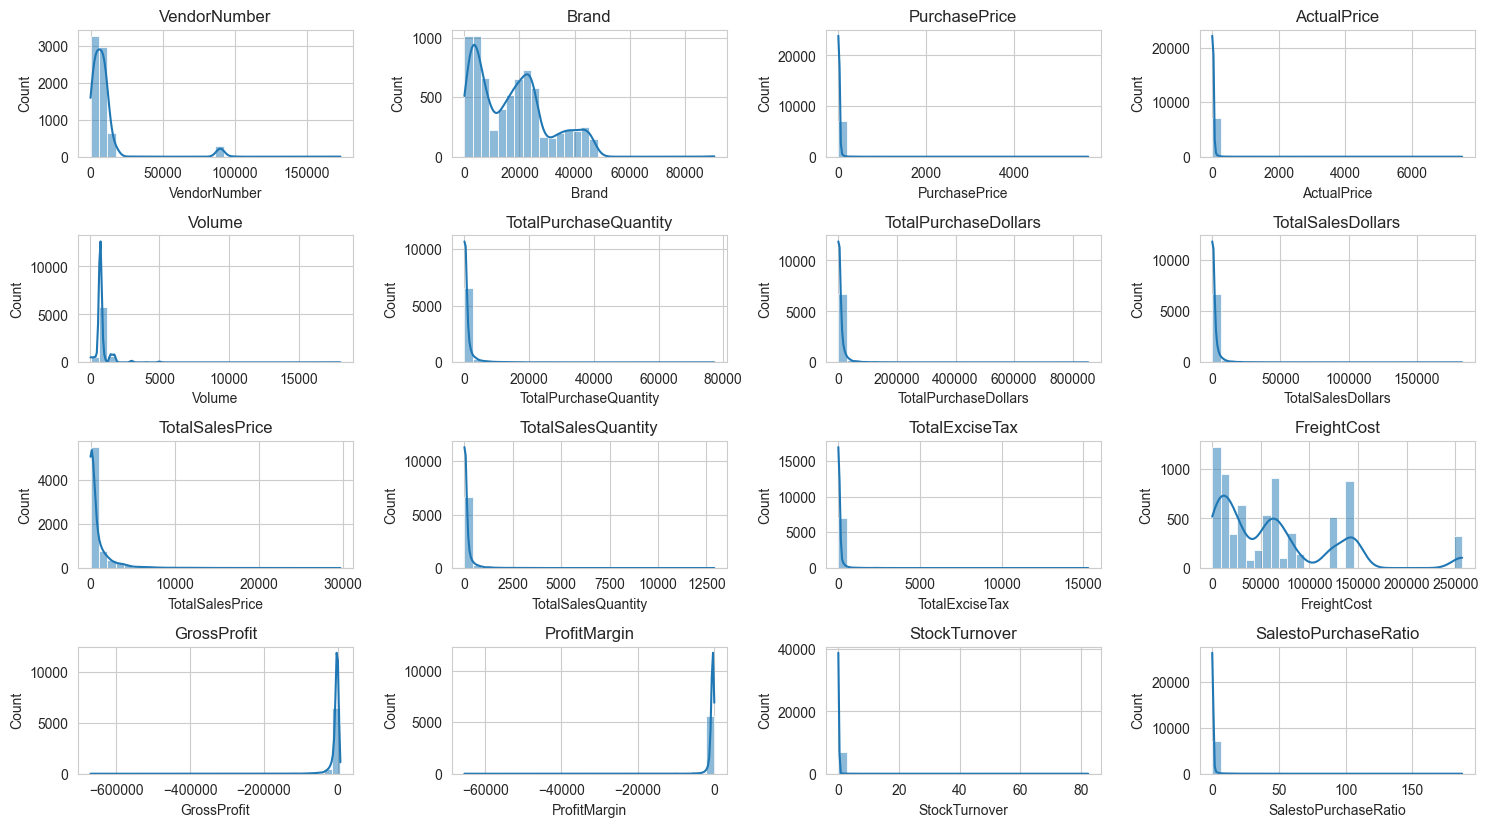

In [77]:
# Distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(5,4,i+1)  #adjust Grid Layout
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout(),
plt.show()

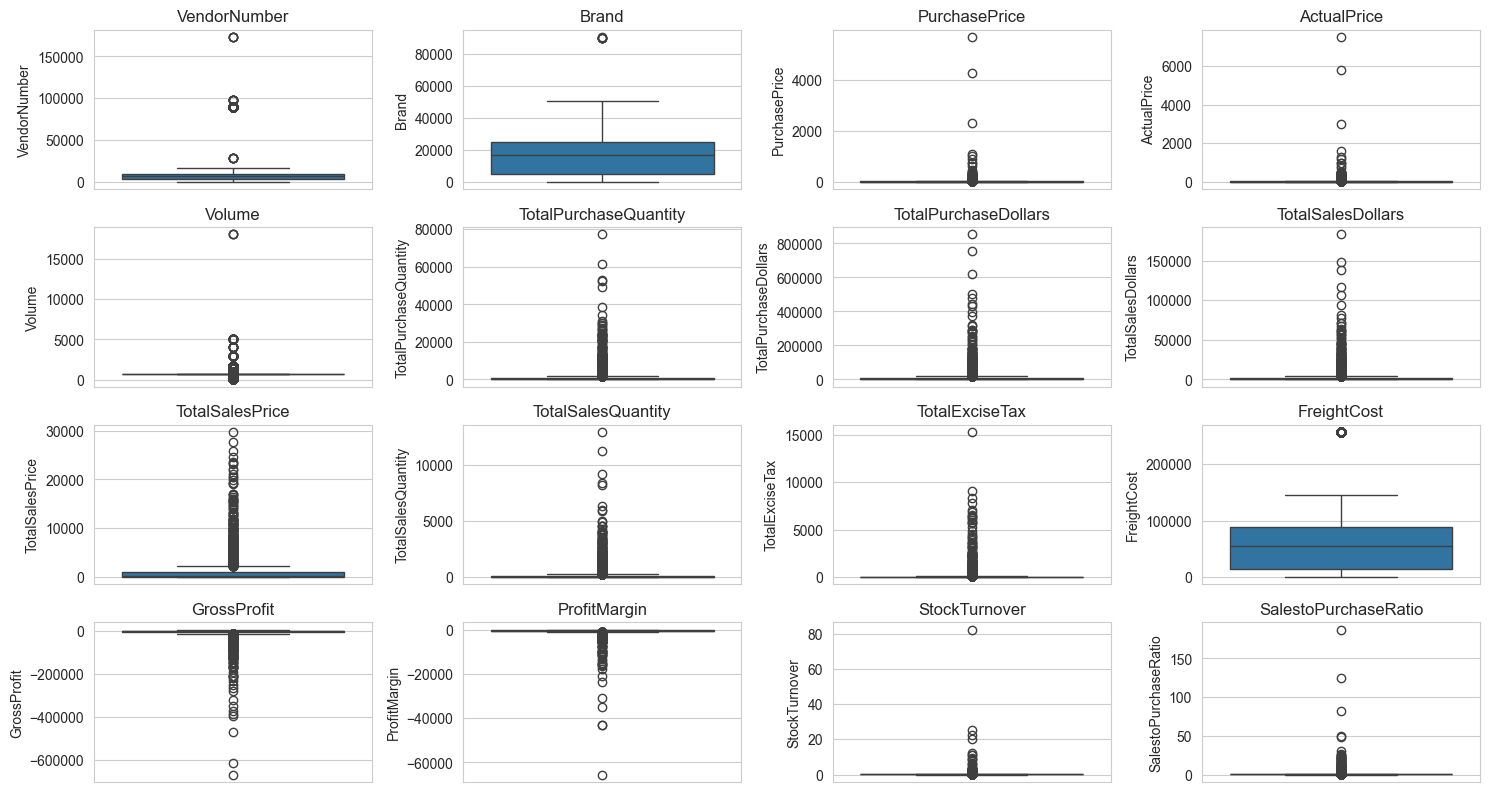

In [78]:
#Outlier detection with Boxplot
plt.figure(figsize=(15,10)),
for i,col in enumerate(numerical_cols):
    plt.subplot(5,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout(),
plt.show()

##### Summary Insights:

##### Negative & Zero Values:

* Gross Profit - Minimum Value  is -669764.28, indicating losses. Some Products or Transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
* Profit Margin :- Has a minimum of which suggests cases where revenue is zero or even lower than costs.
* TotalSales Quantity & Sales Dollars:- Minimum values are 0 meaning some product were purchased but never sold. These could be slow-moving or obsolets stock.

##### Outliers Indicated by high standard Deviations

* Purchase & Actual Prices: The max values (5681.81 & 7499.99) are significantly higher than the mean(18.75 & 27.55), indicating potential premimum products.
* Freight Cost: Huge variation, from 0.27 to 257032.07, suggests logistics inefficients or bulk shipments.
* Stock Turnover: Ranges from 0 to 82.30, implying some products sell extremly fasts while others remain in stock indefinetly. Value more than 1 indicates that sold qty for that product is higher than purchased qty due toeither sales are being fulfilled from older stock.

In [79]:
#lets Filter the data by removing inconsistance
df = pd.read_sql_query("""Select *
from vendor_sales_summary
where GrossProfit > 0
and ProfitMargin > 0
and TotalSalesQuantity > 0""",engine)
df.shape

(550, 18)

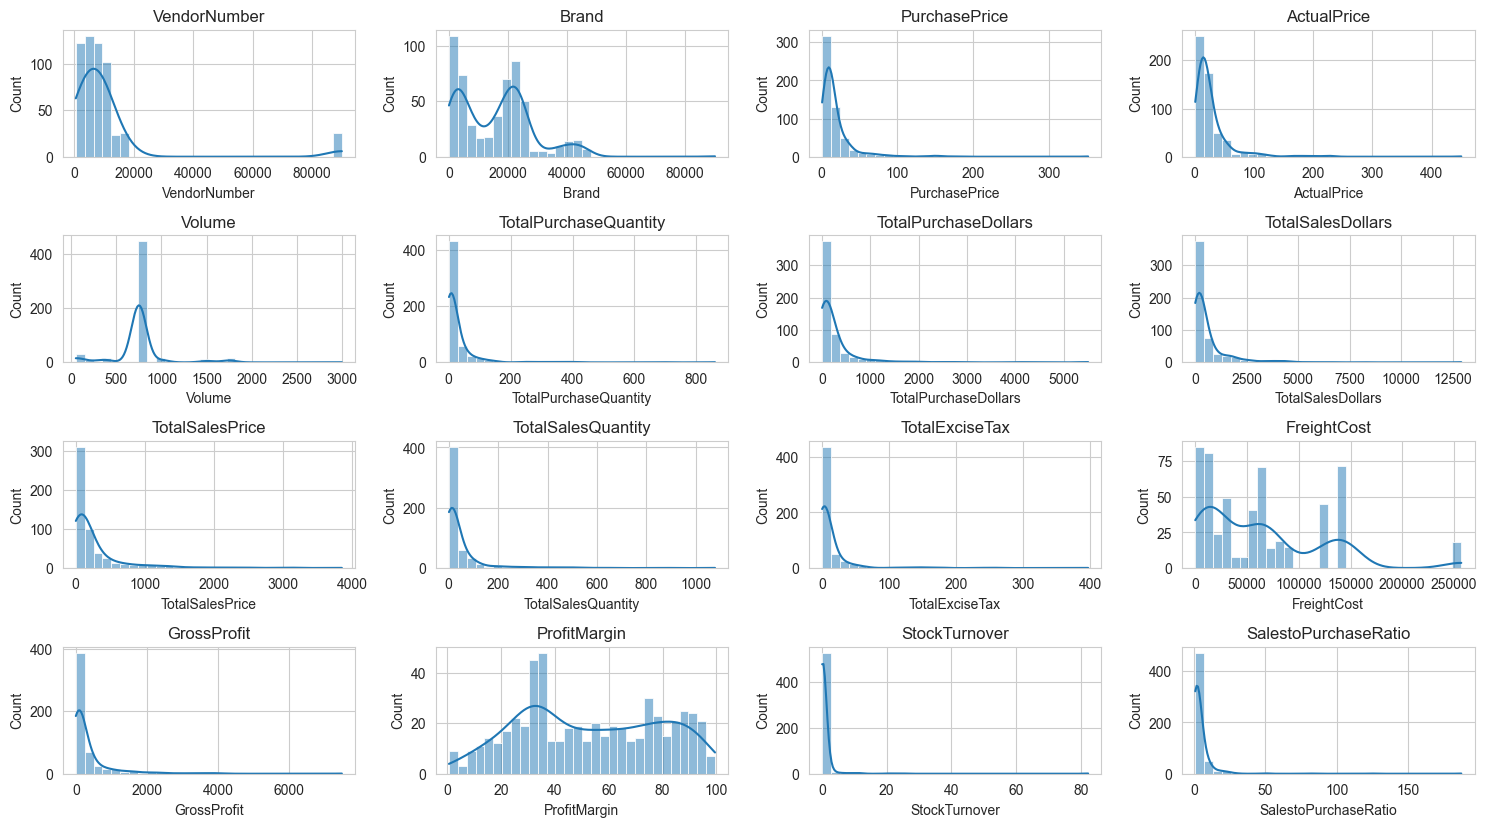

In [80]:
#Distribution plots for numerial column after cleaning the data
numerical_cols = df.select_dtypes(include =np.number).columns

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(5,4,i+1) # Adjust grid layout
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout(),
plt.show()

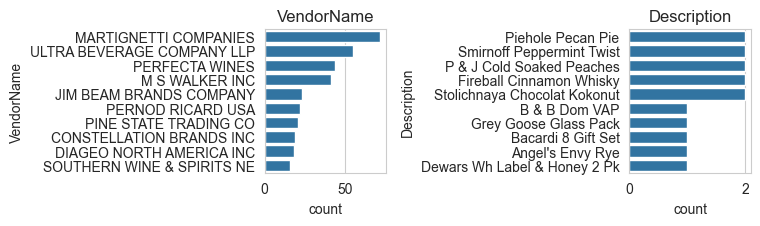

In [81]:
#Count Plot for categorical Value
categorical_cols = ['VendorName','Description']

plt.figure(figsize=(15,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(5,4,i+1) # Adjust grid layout
    sns.countplot(df[col], order=df[col].value_counts().index[:10])
    plt.title(col)
plt.tight_layout(),
plt.show()

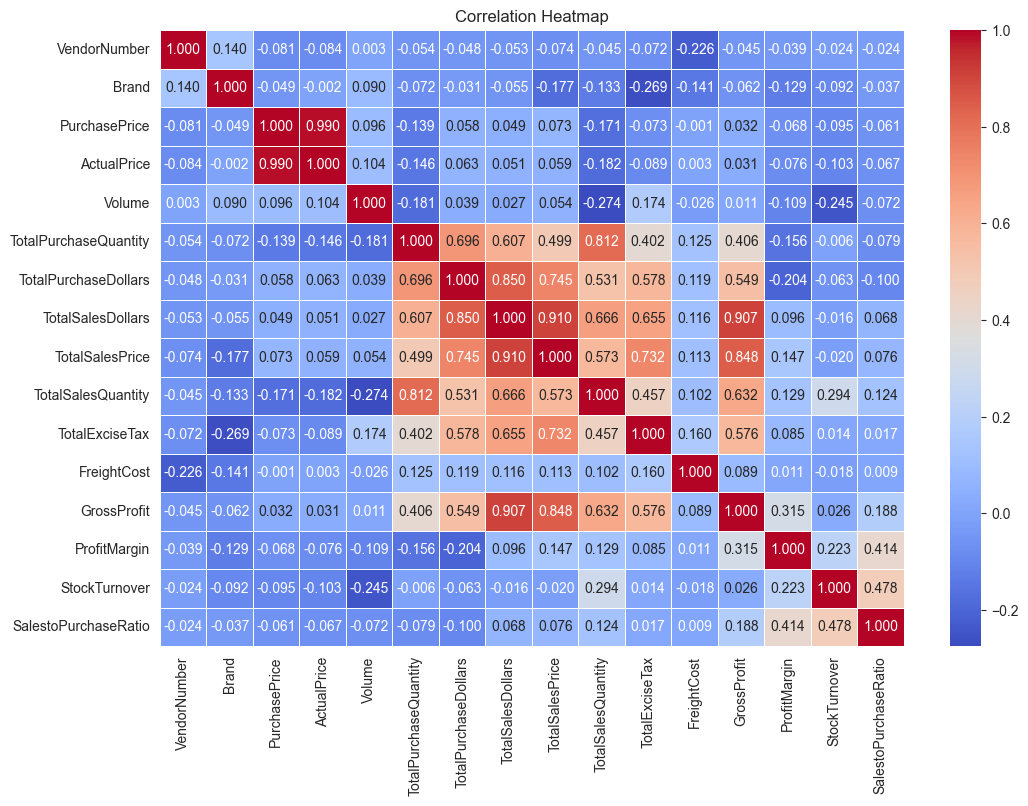

In [82]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
correlaion_matrix = df[numerical_cols].corr()
sns.heatmap(correlaion_matrix,annot=True,fmt = '.3f',cmap='coolwarm',linewidths=0.7)
plt.title('Correlation Heatmap')
plt.show()

##### Correlation Insights
* Purchase price has weak correlations with TotalSalesDollars(0.049) and GrossProfit(0.032), Suggesting that price variation do not singnificantly impact sales revenue or profit.

* Strong Correlations between total purchases quantity and total sales qty (0.812), confirming efficient turnover.

##### Data Analysis

#### 1st Research Question :- Identify Brands that need Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins;

In [83]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'
}).reset_index()
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,12 Days of Pearls Gift Set,49.95,85.606
1,1800 Select Silver Tequila,269.91,92.431
2,A Bichot Chablis Vaucopins,115.96,65.747
3,A Bichot Merc Champs M,171.96,83.659
4,Absolut Grapevine Vodka,499.66,43.361
...,...,...,...
540,Yellow Tail Moscato Bubbles,38.97,34.642
541,Z-52 Znfdl Lodi Old Vines,759.05,97.949
542,Zardetto Pros di Coneg Brut,60.39,35.618
543,Zinsane Znfdl Lodi,3691.38,94.547


In [84]:
low_Sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15) # less than 15%
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85) # greter than 85%

print(f'Sales Threshold is {low_Sales_threshold}\n'
      f'Margin Threshold is {high_margin_threshold}')

Sales Threshold is 67.704
Margin Threshold is 84.93939999999999


In [85]:
#filter brands with low sales but high profit margins.
target_brands =brand_performance[
    (brand_performance['TotalSalesDollars']<= low_Sales_threshold) &
    (brand_performance['ProfitMargin']>= high_margin_threshold)
]
target_brands

,Description,TotalSalesDollars,ProfitMargin
0,12 Days of Pearls Gift Set,49.95,85.606
6,Absolut Pears,35.82,91.122
337,Mojoshot Blue Lagoon RTD,48.51,95.485
360,Old St Nick's Egg Nog,59.90,94.324
381,Piehole Apple Pie,52.47,91.767
452,St Elder Elderflower Liqueur,48.51,88.291
488,Three Olives Grape Vodka,5.94,88.047


In [86]:
print('Brands with low sales but high profit margins:')
target_brands = target_brands.sort_values('TotalSalesDollars')
target_brands.to_csv(r'brand need Promotion_Pricing Adjustment.csv',index=False)
target_brands

Brands with low sales but high profit margins:


,Description,TotalSalesDollars,ProfitMargin
488,Three Olives Grape Vodka,5.94,88.047
6,Absolut Pears,35.82,91.122
452,St Elder Elderflower Liqueur,48.51,88.291
337,Mojoshot Blue Lagoon RTD,48.51,95.485
0,12 Days of Pearls Gift Set,49.95,85.606
381,Piehole Apple Pie,52.47,91.767
360,Old St Nick's Egg Nog,59.90,94.324


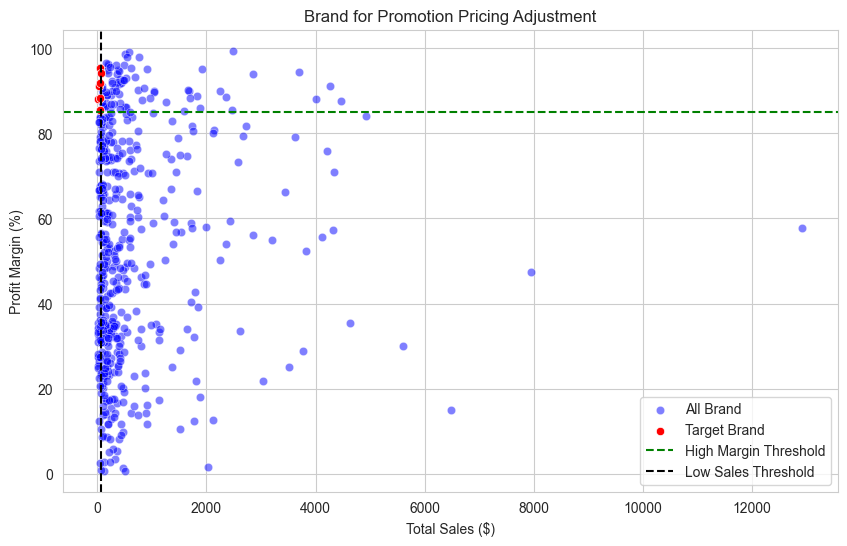

In [87]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x = 'TotalSalesDollars',y = 'ProfitMargin',color='Blue',label='All Brand',alpha=0.5)
sns.scatterplot(data=target_brands,x='TotalSalesDollars',y='ProfitMargin',color='red',label='Target Brand')

plt.axhline(high_margin_threshold,linestyle='--',color='Green',label='High Margin Threshold')
plt.axvline(low_Sales_threshold,linestyle='--',color='black',label='Low Sales Threshold')

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brand for Promotion Pricing Adjustment')
plt.legend()
plt.grid(True)
plt.show()

In [88]:
# To see Better Visualization
brand_performance= brand_performance[brand_performance['TotalSalesDollars']<1000]

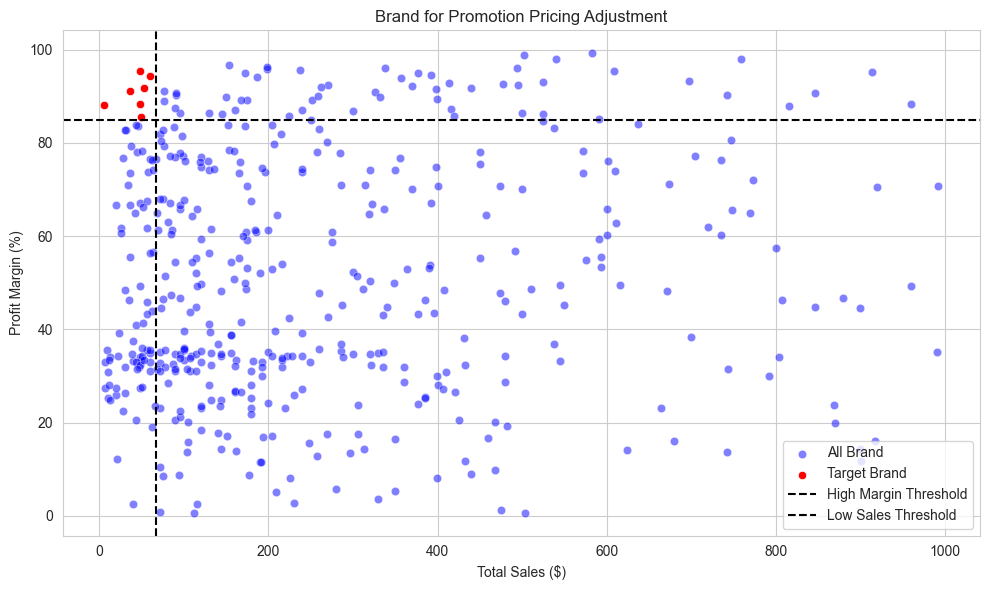

In [89]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x = 'TotalSalesDollars',y = 'ProfitMargin',color='Blue',label='All Brand',alpha=0.5)
sns.scatterplot(data=target_brands,x='TotalSalesDollars',y='ProfitMargin',color='red',label='Target Brand')

plt.axhline(high_margin_threshold,linestyle='--',color='black',label='High Margin Threshold')
plt.axvline(low_Sales_threshold,linestyle='--',color='black',label='Low Sales Threshold')

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brand for Promotion Pricing Adjustment')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2nd Research Question :- Which Vendors and brands demonstrate the highest sales performance ?

In [90]:
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)
top_vendors

VendorName
MARTIGNETTI COMPANIES         53290.90
ULTRA BEVERAGE COMPANY LLP    38431.17
M S WALKER INC                27422.84
BROWN-FORMAN CORP             23988.19
BACARDI USA INC               21242.26
DIAGEO NORTH AMERICA INC      18021.78
PERFECTA WINES                17347.99
PERNOD RICARD USA             15242.42
STATE WINE & SPIRITS          11477.65
SOUTHERN WINE & SPIRITS NE     9596.02
Name: TotalSalesDollars, dtype: float64

In [91]:
top_brands

Description
Buehler Chard RRV               12925.22
Bacardi Twin Pack 2/750mls       7956.02
DiSaronna Amaretto Sour VAP      6483.02
Robert Hall Cab Svgn             5609.99
Jack Daniels Bruins Glass Pk     4930.38
Baracchi O'Lillo                 4640.13
Jack Daniels Honey + Glass       4459.09
Parducci True Grit 11 Cab Sv     4333.29
Capt Morgan White PET            4317.84
Pavilion St Pierre Cdu Rhone     4255.74
Name: TotalSalesDollars, dtype: float64

In [92]:
# To show  the data in readable format
def format_dollars(value):
    if value>=1000000:
        return f'{value/1000000:.2f}M'
    elif value>=1000:
        return f'{value/1000:.2f}K'
    else:
        return str(value)

In [93]:
top_vendors.apply(format_dollars)

VendorName
MARTIGNETTI COMPANIES         53.29K
ULTRA BEVERAGE COMPANY LLP    38.43K
M S WALKER INC                27.42K
BROWN-FORMAN CORP             23.99K
BACARDI USA INC               21.24K
DIAGEO NORTH AMERICA INC      18.02K
PERFECTA WINES                17.35K
PERNOD RICARD USA             15.24K
STATE WINE & SPIRITS          11.48K
SOUTHERN WINE & SPIRITS NE     9.60K
Name: TotalSalesDollars, dtype: object

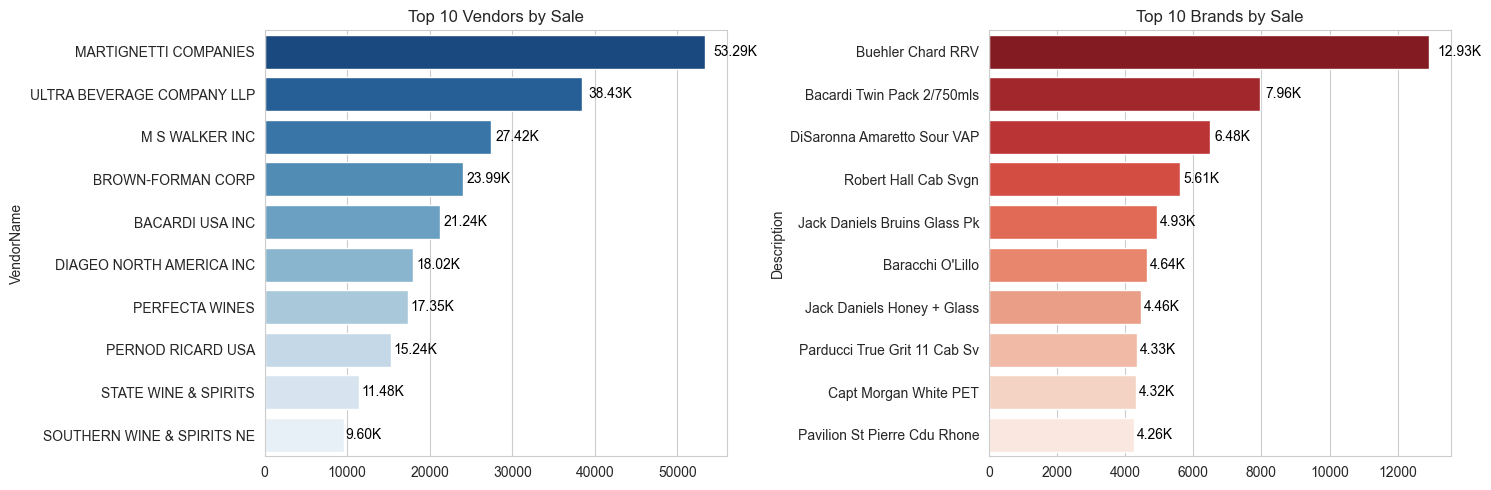

In [94]:
plt.figure(figsize=(15,5))
# Plot for Top Vendors
plt.subplot(1,2,1)
ax1=sns.barplot(y=top_vendors.index,x=top_vendors.values,palette='Blues_r')
plt.title('Top 10 Vendors by Sale')

for bar in ax1.patches:
    ax1.text(bar.get_width() +(bar.get_width() * 0.02),
             bar.get_y()+ bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha='left',va='center',fontsize=10,color='Black')


#Plot for the Brands
plt.subplot(1,2,2)
ax2=sns.barplot(y=top_brands.index.astype(str),x=top_brands.values,palette='Reds_r')
plt.title('Top 10 Brands by Sale')

for bar in ax2.patches:
    ax2.text(bar.get_width() +(bar.get_width() * 0.02),
             bar.get_y()+ bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha='left',va='center',fontsize=10,color='Black')

plt.tight_layout()
plt.show()

#### 3rd Research Question :- Which vendors contribute the most to total purchase dollars

In [95]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum',
}).reset_index()
vendor_performance.shape

(61, 4)

In [96]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [97]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [98]:
# Display Top 10 vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
29,MARTIGNETTI COMPANIES,25.36K,27.94K,53.29K,17.71
53,ULTRA BEVERAGE COMPANY LLP,15.15K,23.28K,38.43K,10.58
26,M S WALKER INC,9.64K,17.79K,27.42K,6.73
12,DIAGEO NORTH AMERICA INC,9.48K,8.54K,18.02K,6.62
1,BACARDI USA INC,9.27K,11.97K,21.24K,6.48
36,PERFECTA WINES,8.22K,9.13K,17.35K,5.74
37,PERNOD RICARD USA,7.01K,8.23K,15.24K,4.90
13,DISARONNO INTERNATIONAL LLC,5.68K,1.73K,7.41K,3.97
46,STATE WINE & SPIRITS,5.32K,6.15K,11.48K,3.72
3,BROWN-FORMAN CORP,4.66K,19.33K,23.99K,3.25


In [99]:
print(top_vendors['PurchaseContribution%'].sum())

69.7


In [100]:
top_vendors['cumulative_PurchaseContribution%']= top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,cumulative_PurchaseContribution%
29,MARTIGNETTI COMPANIES,25.36K,27.94K,53.29K,17.71,17.71
53,ULTRA BEVERAGE COMPANY LLP,15.15K,23.28K,38.43K,10.58,28.29
26,M S WALKER INC,9.64K,17.79K,27.42K,6.73,35.02
12,DIAGEO NORTH AMERICA INC,9.48K,8.54K,18.02K,6.62,41.64
1,BACARDI USA INC,9.27K,11.97K,21.24K,6.48,48.12
36,PERFECTA WINES,8.22K,9.13K,17.35K,5.74,53.86
37,PERNOD RICARD USA,7.01K,8.23K,15.24K,4.90,58.76
13,DISARONNO INTERNATIONAL LLC,5.68K,1.73K,7.41K,3.97,62.73
46,STATE WINE & SPIRITS,5.32K,6.15K,11.48K,3.72,66.45
3,BROWN-FORMAN CORP,4.66K,19.33K,23.99K,3.25,69.70


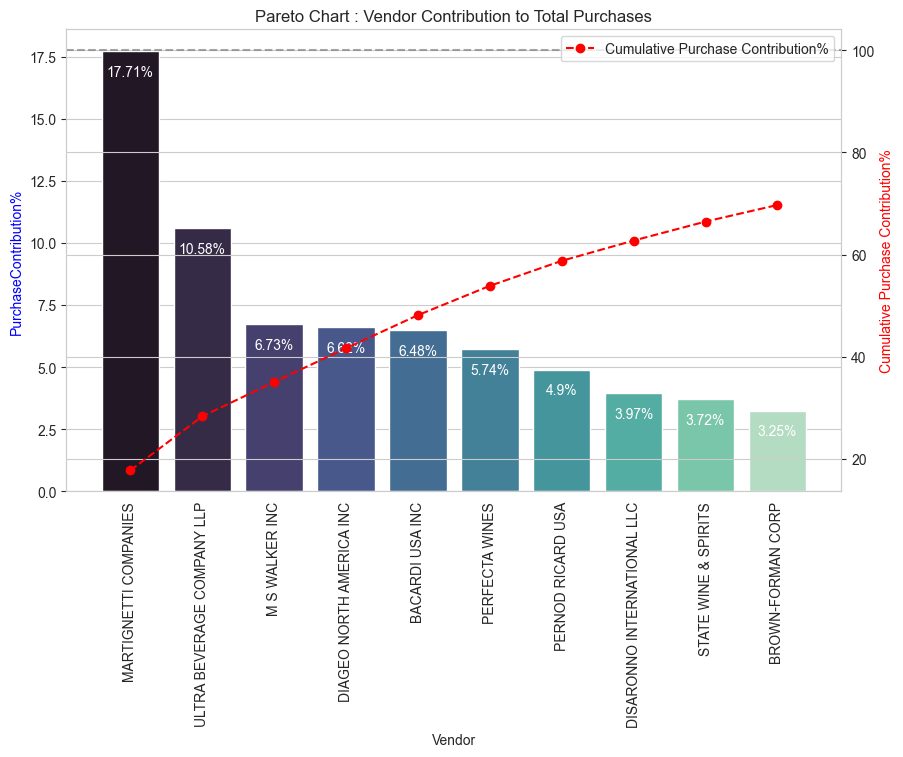

In [102]:
fig, ax1 = plt.subplots(figsize=(10,6))

#Bar Plot for purchase contribution%
sns.barplot(x=top_vendors['VendorName'],y=top_vendors['PurchaseContribution%'], palette='mako',ax=ax1)

for i,value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i,value - 1,str(value)+'%', ha='center',fontsize=10,color='White')

#line plot for Cumulative contributions%
ax2=ax1.twinx()
ax2.plot(top_vendors['VendorName'],top_vendors['cumulative_PurchaseContribution%'],color='red',marker='o',linestyle='dashed',label='Cumulative Purchase Contribution%'  )


ax1.set_xticklabels(top_vendors['VendorName'],rotation=90)
ax1.set_ylabel('PurchaseContribution%',color='blue')
ax2.set_ylabel('Cumulative Purchase Contribution%',color='red')
ax1.set_xlabel('Vendor')
ax1.set_title('Pareto Chart : Vendor Contribution to Total Purchases')

ax2.axhline(y=100,color='gray',linestyle='dashed',alpha=0.7)
ax2.legend(loc='upper right')
plt.show()


#### 4th Research Question : How much of total procurement is dependent on the top vendors

In [103]:
print(f'Total Purchase Contribution of top 10 Vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%')

Total Purchase Contribution of top 10 Vendors is 69.7%


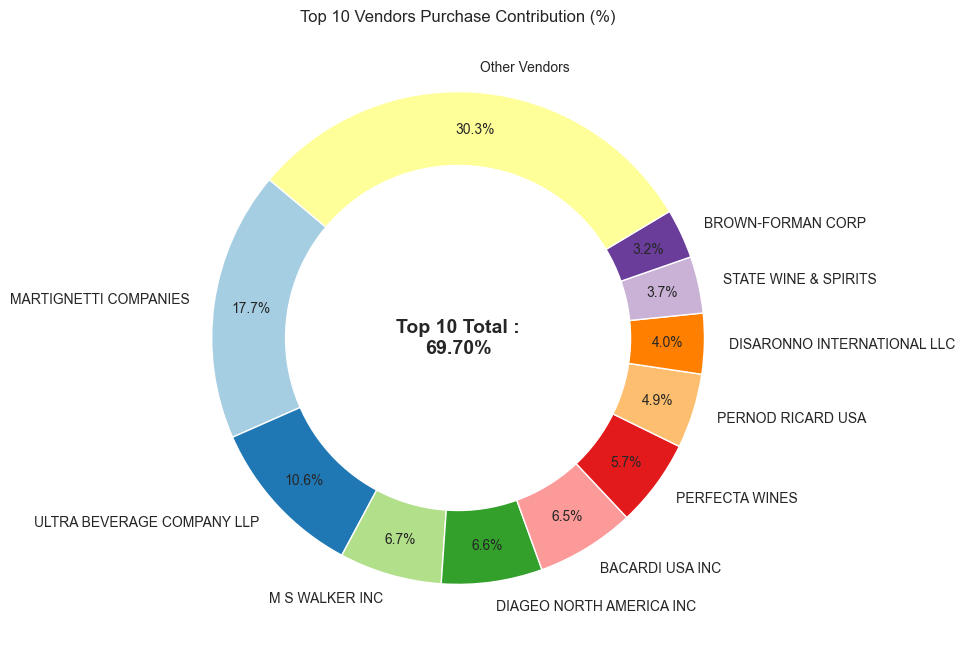

In [104]:
vendors = list(top_vendors['VendorName'].values)
Purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contributions= sum(Purchase_contributions)
remaining_contributions = 100 - total_contributions


# append Other Vendors Category

vendors.append('Other Vendors')
Purchase_contributions.append(remaining_contributions)

#Donut Chart
fig,ax = plt.subplots(figsize=(10,8))
wedges,texts,autotexts = ax.pie(Purchase_contributions,labels=vendors,autopct='%1.1f%%',
                                startangle=140,pctdistance=0.85,colors=plt.cm.Paired.colors)


#Draw a white circle in the center to create a donut effect
center_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(center_circle)

#Add Total Contribution annotation in the center
plt.text(0,0,f'Top 10 Total :\n{total_contributions :.2f}%',fontsize=14,fontweight='bold', ha='center',va='center')

plt.title('Top 10 Vendors Purchase Contribution (%)')
plt.show()

#### 5th Research Question : Does Purchasing in bulk Reduce the unit price, and what is the optimal purchase volume for cost saving ?

In [105]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [106]:
# Divide TotalPurchaseQuantity in 3 Category(large,Medium,Small) on quantity basic using pd.qcut:- it create 3 equal bucket and will save in order
df['Ordersize'] = pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['Small','Medium','Large'])

In [107]:
df[['Ordersize','TotalPurchaseQuantity']]

,Ordersize,TotalPurchaseQuantity
0,Large,343
1,Small,1
2,Small,2
3,Large,62
4,Medium,5
...,...,...
545,Small,2
546,Large,54
547,Large,68
548,Large,24


In [108]:
df.groupby('Ordersize')['UnitPurchasePrice'].mean()

Ordersize
Small     25.624412
Medium    16.906391
Large     10.241525
Name: UnitPurchasePrice, dtype: float64

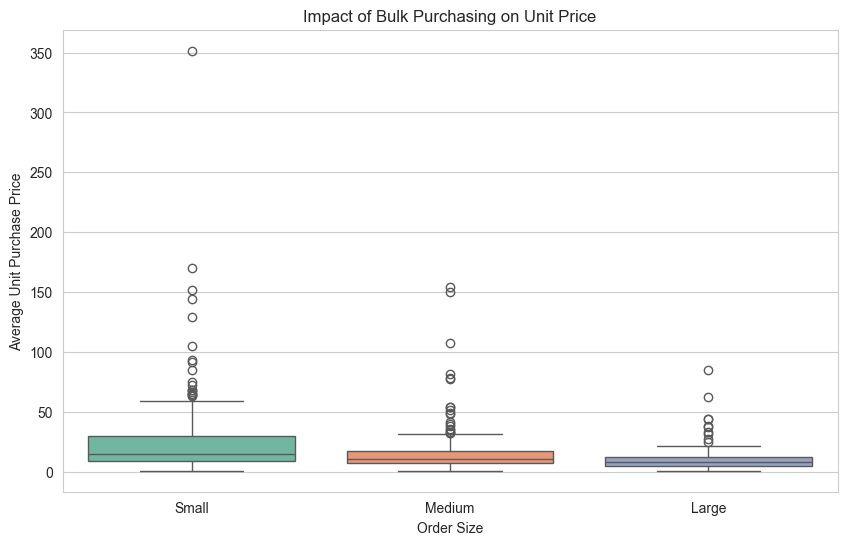

In [109]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Ordersize',y='UnitPurchasePrice',palette='Set2')
plt.title('Impact of Bulk Purchasing on Unit Price')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Purchase Price')
plt.show()

##### Some Insights:-
* Vendor buying in bulk(large order size) get the lowest unit price,meaning higher margins if they can manage inventory efficiently.
* The Price difference between Small and Large orders is substantial(-72% reduction in unit cost)
* This Suggests that bulk pricing strategies successfully vendors to purchase in large volume,leading to higher overall sales despite lower per-unit revenue.

#### 6th Research Question :- Which Vendors have low inventory turnover, indicating excess stock and slow-moving productss ?

In [111]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.019000
EDRINGTON AMERICAS,0.031750
MOET HENNESSY USA INC,0.041000
STE MICHELLE WINE ESTATES,0.049200
OLE SMOKY DISTILLERY LLC,0.055000
BANFI PRODUCTS CORP,0.056000
Dunn Wine Brokers,0.057333
FORTUNE WINE BROKERS LLC,0.059500
VRANKEN AMERICA,0.061000


#### 7th Research Question :- How much capital is locked  in unsold inventory per vendor contribute the most to it

In [112]:
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity'])*df['PurchasePrice']
print("Total Unsold Capital :- ",format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital :-  -87600.01999999999


In [113]:
# Aggregate Capital locked  per vendor
inventory_values_per_vendor= df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()

#sort Values with the highest locked capital
inventory_values_per_vendor = inventory_values_per_vendor.sort_values(by='UnsoldInventoryValue',ascending=False)
inventory_values_per_vendor['UnsoldInventoryValue']=inventory_values_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_values_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
13,DISARONNO INTERNATIONAL LLC,679.29
4,CAMPARI AMERICA,247.04000000000002
2,BANFI PRODUCTS CORP,240.60000000000002
24,LABELLE VYDS AND WINERY,155.38
15,Dunn Wine Brokers,142.78
10,DELICATO VINEYARDS INC,113.62
41,PSP WINES,103.84
47,STE MICHELLE WINE ESTATES,64.87
34,OLE SMOKY DISTILLERY LLC,42.51
52,TRINCHERO FAMILY ESTATES,32.18


####  8th Research Questions :- What is the 95% Confidence intervals for  profit margins of top-Performing and low-Performing Vendors

### Statistics :
Statistics is the branch of mathematics  that deals with collecting, organizing, analyzing, interpretin, and presenting data. It helps us make decisions or draw  conclusion when faced with uncertainty.

The two main types of statistics.
* Descriptive statistics:- It Summarizes and describe the characterstics of a dataset-Descriptive Statistics use measures like the mean,media,and standard deviation
* Inferential Statistics:- It uses Sample data to make predictions or draw conclusion about a larger populations. Inferential Statistics often involves hypothesis testing and predictions

#### A Confidence Interval (CI) is a range values that contains the true valueo of somthing we are trying measure like the average height  of students or average income of a population.

* Instead of saying :"The Average Height is 165 cm".
* We can say:- "we are 95% confident the average height is between 160 cm and 170 cm."

In [204]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)
print('top_threshold :',top_threshold)
print('low_threshold :',low_threshold)

top_threshold : 588.635
low_threshold : 99.9825


In [222]:
top_vendors= df[df['TotalSalesDollars']>=top_threshold]['ProfitMargin'].dropna()
low_vendors= df[df['TotalSalesDollars']<=low_threshold]['ProfitMargin'].dropna()


In [223]:
low_vendors

1      61.817
18     34.197
21     27.514
23     33.317
50     30.909
        ...  
538    91.226
539    40.946
544    49.333
545    73.741
549    77.165
Name: ProfitMargin, Length: 138, dtype: float64

In [233]:
# To Calculate the confidence interval
def confidence_interval(data,confidence=0.95):
    mean_val = np.mean(data)
    standard_error = np.std(data,ddof=1)/np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * standard_error
    return mean_val,mean_val-margin_of_error,mean_val+margin_of_error

Top_vendors 95%  CI: (54.44),62.99,mean:58.72
low_vendors 95%  CI: (47.07),55.19,mean:51.13


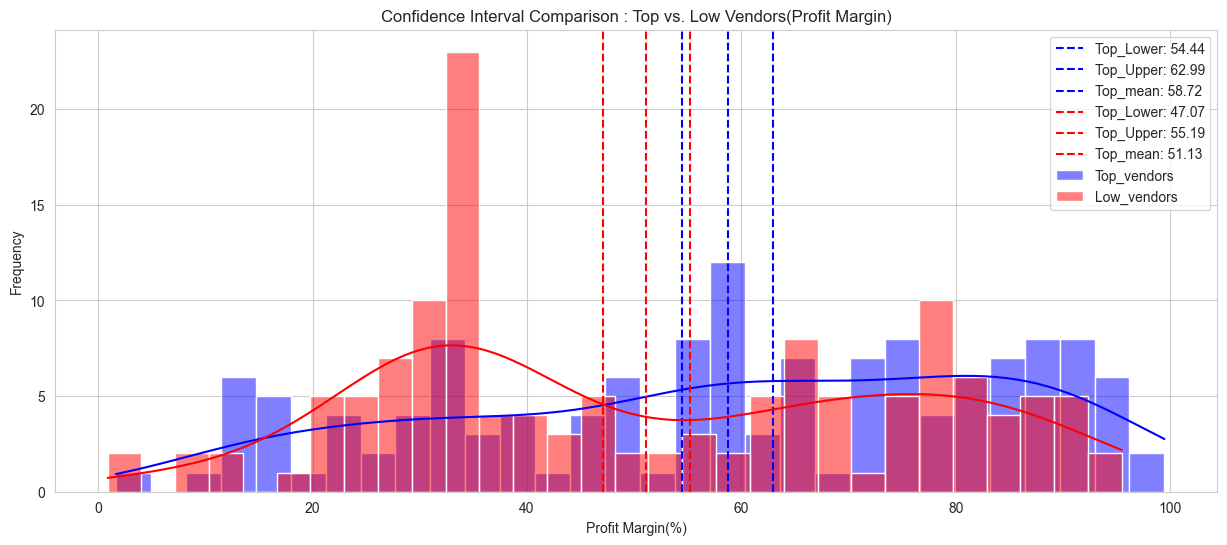

In [235]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f'Top_vendors 95%  CI: ({top_lower :.2f}),{top_upper :.2f},mean:{top_mean:.2f}')
print(f'low_vendors 95%  CI: ({low_lower :.2f}),{low_upper :.2f},mean:{low_mean:.2f}')

plt.figure(figsize=(15,6))

# Top Vendors  Plot
sns.histplot(top_vendors, kde=True,color='blue',bins=30,alpha=0.5,label='Top_vendors')
plt.axvline(top_lower, color='blue',linestyle='--',label=f'Top_Lower: {top_lower:.2f}')
plt.axvline(top_upper, color='blue',linestyle='--',label=f'Top_Upper: {top_upper:.2f}')
plt.axvline(top_mean, color='blue',linestyle='--',label=f'Top_mean: {top_mean:.2f}')


# Low Vendors Plot
sns.histplot(low_vendors, kde=True,color='red',bins=30,alpha=0.5,label='Low_vendors')
plt.axvline(low_lower, color='red',linestyle='--',label=f'Top_Lower: {low_lower:.2f}')
plt.axvline(low_upper, color='red',linestyle='--',label=f'Top_Upper: {low_upper:.2f}')
plt.axvline(low_mean, color='red',linestyle='--',label=f'Top_mean: {low_mean:.2f}')


# Finalize Plot
plt.title('Confidence Interval Comparison : Top vs. Low Vendors(Profit Margin)')
plt.xlabel('Profit Margin(%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

#### Hypothessis Testing:-
* Hypothessis testing compares two opposite idea about a group of people or things and uses data from a small part of that group (a Simple) to decide which idea is more likely true. We collect and study the sample data to check if the claim is correct.

    * Null Hypothessis (Ha) : The starting  assumption. for example, 'The average visits are 50.'
    * Alternative Hypothessis (H1) : The opposite, saying there is a difference. For example, 'The average visits are not 50.'

#### Our problem statement for Hypothesis :Is there a significant difference in profit margins between top performing and low performing vendor ?
#### Hypothesis:
  *Ho(Null Hypothesis):- There is no significant difference in the mean profit margins of top-performing and low-performing vendors.
  *H1(Alternative Hypothesis):- The mean profit margins of top-performing and low-performing vendors are significantly different.

In [114]:
from scipy.stats import ttest_ind

top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

# Perfomar Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

#Print result
print(f'T-Statistic: {t_stat:.4f}, p-Value: {p_value:.4f}')

# print(f'p-value : {p_value : .4f}')

if p_value <0.05:
    print('Reject H0:- There is a significant difference is profit  margin between  top and low performing vendors.')
else:
    print('Fail to reject H0:- No significant difference is profit  margin')

T-Statistic: 2.5414, p-Value: 0.0116
Reject H0:- There is a significant difference is profit  margin between  top and low performing vendors.
